# Análise Integrada de HIV em Gestantes

Este notebook unifica as análises feitas em abordagens separadas, reunindo as etapas de:
1. **Tratamento Fidedigno e Tradução de R para Python** (Remoção de Duplicadas e Limpeza por Dicionários DataSUS, Testes Estatísticos Qui-Quadrado)
2. **Exploração Demográfica, Geográfica e Modelagem Avançada (Séries Temporais e Machine Learning)**

Ambas as lógicas foram devidamente combinadas de forma otimizada numa única pipeline.


## 1. Importação de Bibliotecas e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import warnings
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy.stats import chi2_contingency
from IPython.display import display

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except:
    PROPHET_AVAILABLE = False

try:
    import geobr
    GEOBR_AVAILABLE = True
except:
    GEOBR_AVAILABLE = False

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="magma")
plt.rcParams['figure.figsize'] = (14, 7)
GEOBR_AVAILABLE = True

### 1. Leitura de Arquivos CSV
Nesta etapa, lemos todos os arquivos `.dbc` presentes na subpasta `Banco-dados`. Cada arquivo é convertido para `.dbf` temporariamente, lido e depois apagado.

In [2]:
# Carregar dados diretamente do CSV consolidado
csv_file = 'HIV-Gestante-2018-2024.csv'
print(f"Lendo arquivo: {csv_file}")
data_raw = pd.read_csv(csv_file, encoding='utf-8')
print("Número total de linhas antes da remoção de duplicatas:", len(data_raw))


Lendo arquivo: HIV-Gestante-2018-2024.csv
Número total de linhas antes da remoção de duplicatas: 53199


### 2. Tratamento e Identificação de Duplicatas
Vamos buscar linhas duplicadas levando em consideração todas as colunas de notificação e datas.

In [3]:
# Verificar duplicatas com base nas colunas escolhidas no R
cols_dup = [
    'TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'NU_ANO', 'SG_UF_NOT', 'ID_MUNICIP', 'ID_REGIONA', 
    'DT_DIAG', 'SEM_DIAG', 'NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 
    'SG_UF', 'ID_MN_RESI', 'ID_RG_RESI', 'ID_PAIS', 'ANT_EVLABO', 'PRE_PRENAT', 'PRE_UFREL', 
    'PRE_MUNIRE', 'PRE_ANTRET', 'PRE_DT_RET', 'PAR_UFPART', 'PRE_MUNIPA', 'PAR_DT_PAR', 
    'PAR_TIPO', 'PAR_ANTIDU', 'PAR_EVOLUC', 'PAR_INICPR'
]

# Quantas duplicatas nós temos?
duplicados = data_raw[data_raw.duplicated(subset=cols_dup, keep=False)]
print(f"Duplicatas encontradas: {len(duplicados)}")

# Remover duplicatas mantendo apenas o primeiro registro
data = data_raw.drop_duplicates(subset=cols_dup, keep='first').copy()
print("Linhas depois (sem duplicatas):", len(data))

# Cuidar da conversão de variáveis numéricas necessárias (para posterior categorização)
num_cols = ['ANT_EVLABO', 'PRE_PRENAT', 'PAR_TIPO', 'CS_RACA', 'CS_ESCOL_N', 'PAR_EVOLUC', 'NU_ANO', 'SG_UF', 'NU_IDADE_N']
for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Gerar data verdadeira (Para o Script de Machine learning e o Reporting Lag)
data['DT_NOTIFIC'] = pd.to_datetime(data['DT_NOTIFIC'], errors='coerce')
data['ANO'] = data['DT_NOTIFIC'].dt.year
data = data.dropna(subset=['DT_NOTIFIC']).copy()

# --- FILTRO DINAMICO: Remove meses com atraso de notificacao (Reporting Lag) (Lógica do Pedro) ---
# A partir de Jul/2024 os dados do SINAN ficam incompletos (lag de processamento)
ts_raw = data.resample('M', on='DT_NOTIFIC').size()
# Proteção caso Pandas versão velha: tentar 'M'
try:
    ts_raw = data.resample('M', on='DT_NOTIFIC').size()
except ValueError:
    ts_raw = data.resample('M', on='DT_NOTIFIC').size()

media_historica = ts_raw.iloc[:-12].mean()
meses_validos = ts_raw[ts_raw > (media_historica * 0.30)].index
ultima_data_valida = meses_validos.max()
data = data[data['DT_NOTIFIC'] <= ultima_data_valida].copy()

print(f"\nPeríodo útil ajustado (sem LAG): até {ultima_data_valida.strftime('%m/%Y')}")
print("Total de registros pós-filtro temporal:", len(data))

print('[Lógica Pedro Aplicada]: Verificação -> Data final retida no DataFrame:', data['DT_NOTIFIC'].max())

Duplicatas encontradas: 18
Linhas depois (sem duplicatas): 53190

Período útil ajustado (sem LAG): até 06/2024
Total de registros pós-filtro temporal: 53091
[Lógica Pedro Aplicada]: Verificação -> Data final retida no DataFrame: 2024-06-30 00:00:00


### 3. Definição do Dicionário (Recodificação)
Aplicaremos os mapeamentos baseados em categorias documentadas.

In [4]:
# dicionário: diagnóstico
diag_map = {1: "Antes Pré-Natal", 2: "Durante Pré-Natal", 3: "Durante o parto", 4: "Após parto"}
data['diagnostico'] = data['ANT_EVLABO'].map(diag_map)

# dicionário: ano
ano_map = {2020: "2020", 2021: "2021", 2022: "2022", 2023: "2023", 2024: "2024"}
data['ano'] = data['NU_ANO'].map(ano_map)

# dicionário: preNatal
prenat_map = {1: "Sim", 2: "Não", 3: "Ignorado"}
data['preNatal'] = data['PRE_PRENAT'].map(prenat_map)

# dicionário: tipo de parto
tipo_parto_map = {1: "Vaginal", 2: "Cesárea eletiva", 3: "Cesárea Urgência"}
data['tipoParto'] = data['PAR_TIPO'].map(tipo_parto_map)

# dicionário: raca/cor
raca_map = {1: "Branca", 2: "Preta", 3: "Amarela", 4: "Parda", 5: "Indígena"}
data['cs_raca'] = data['CS_RACA'].map(raca_map)

# dicionário: escolaridade
def map_escolaridade(x):
    if pd.isna(x): return np.nan
    x = int(x)
    if x == 43: return "Analfabeto"
    if x in [1, 2, 3]: return "Fundamental Incompleto"
    if x == 4: return "Fundamental Completo"
    if x == 5: return "Médio Incompleto"
    if x == 6: return "Médio Completo"
    if x == 7: return "Superior Incompleto"
    if x == 8: return "Superior Completo"
    return np.nan
data['cs_escol_n'] = data['CS_ESCOL_N'].apply(map_escolaridade)

# Correção e cálculo da idade a partir do campo NU_IDADE_N padrão do datasus
# Geralmente a idade é dada por um código (1xx = horas, 2xx = dias, 3xx = meses, 4xx = anos)
def calc_idade(x):
    if pd.isna(x): return np.nan
    if x <= 4000: return 0  # <1 ano
    if x > 4000: return int(str(int(x))[1:4])
    return np.nan
data['idade_anos'] = data['NU_IDADE_N'].apply(calc_idade)

# Categoria da Idade
def cat_idade(idade):
    if pd.isna(idade): return "N/A"
    if 10 <= idade <= 19: return "Adolescente (10 - 19 anos)"
    if 20 <= idade <= 29: return "Jovem Adulta (20 - 29 anos)"
    if 30 <= idade <= 39: return "Adulta (30 - 39 anos)"
    if idade >= 40: return "Adulta (acima de 40)"
    return "N/A"
data['idade_categoria'] = data['idade_anos'].apply(cat_idade)

# Transformação das categorias de idade para "Categorical" do Pandas de forma a ordenar em visualizações
idade_cats = ["Adolescente (10 - 19 anos)", "Jovem Adulta (20 - 29 anos)", "Adulta (30 - 39 anos)", "Adulta (acima de 40)", "N/A"]
data['idade_categoria'] = pd.Categorical(data['idade_categoria'], categories=idade_cats, ordered=True)

# Classificação por Região
def get_regiao(uf):
    if pd.isna(uf): return "N/A"
    uf = int(uf)
    if uf in [12, 13, 16, 15, 11, 14, 17]: return "Norte"
    if uf in [27, 29, 23, 21, 25, 26, 22, 24, 28]: return "Nordeste"
    if uf in [52, 51, 50]: return "Centro-Oeste"
    if uf == 53: return "Distrito Federal"
    if uf in [32, 31, 33, 35]: return "Sudeste"
    if uf in [41, 42, 43]: return "Sul"
    return "N/A"
data['regiao'] = data['SG_UF'].apply(get_regiao)


### 3.1. Adaptações de Engenharia de Dados (Transição para ML)

In [5]:
# Adaptação para Análises Multivariadas e Modelagem
# Criaremos as principais referências temporais e geográficas exigidas nos modelos preditivos

df = data.copy()

# A análise do Pedro requer nomes específicos e variáveis limpas:
df['IDADE_REAL'] = df['idade_anos'].replace(0, np.nan) # Evitar distorções onde 0 poderia ser <1
df['ANO'] = pd.to_numeric(df['ano'], errors='coerce')
df['SG_UF_NUM'] = pd.to_numeric(df['SG_UF'], errors='coerce')

# Convertendo DT_NOTIFIC para datetime a fim de podermos criar as Séries Temporais
# DT_NOTIFIC original: '20201015' (YYYYMMDD) etc
df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'], format='%Y%m%d', errors='coerce')

print("Adaptações do DataFrame concluídas.")


Adaptações do DataFrame concluídas.


### 4. Resumos de Frequência Básica
Validando algumas distribuições.

In [6]:
print("=== Diagnóstico ===")
print(data['diagnostico'].value_counts(dropna=False))
print("")
print("=== Categoria da Idade ===")
print(data['idade_categoria'].value_counts(dropna=False))


=== Diagnóstico ===
diagnostico
Antes Pré-Natal      31293
Durante Pré-Natal    18585
Durante o parto       2735
Após parto             472
NaN                      6
Name: count, dtype: int64

=== Categoria da Idade ===
idade_categoria
Jovem Adulta (20 - 29 anos)    26814
Adulta (30 - 39 anos)          16541
Adolescente (10 - 19 anos)      6910
Adulta (acima de 40)            2194
N/A                              632
Name: count, dtype: int64


### 5. Casos Acumulados por Região/Ano
Gráfico de linhas da evolução.

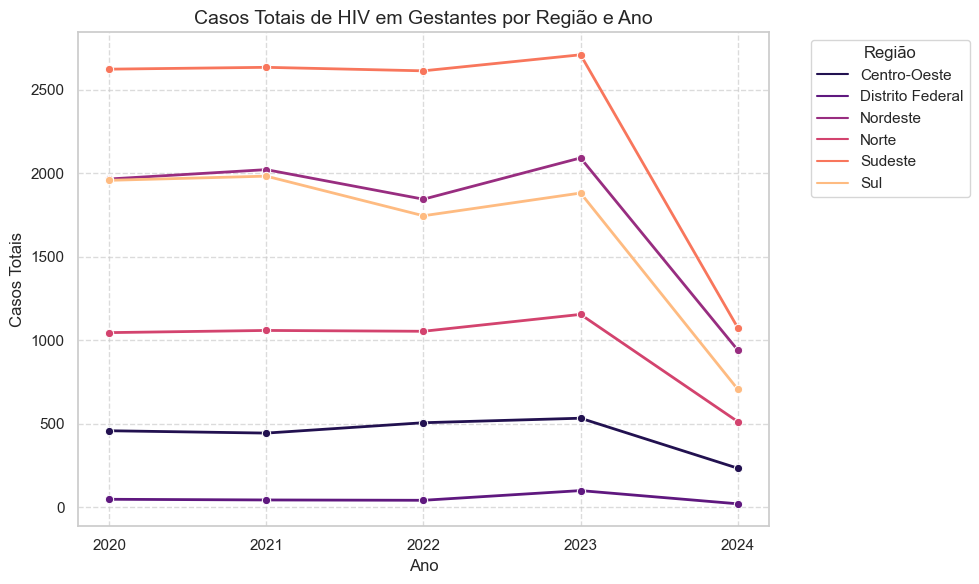

In [7]:
# Filtrar valores não preenchidos
dados_agrupados_regiao = data[data['regiao'] != "N/A"].groupby(['ano', 'regiao']).size().reset_index(name='casos_totais')

plt.figure(figsize=(10, 6))
sns.lineplot(data=dados_agrupados_regiao, x='ano', y='casos_totais', hue='regiao', marker='o', linewidth=2)
plt.title("Casos Totais de HIV em Gestantes por Região e Ano", fontsize=14)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Casos Totais", fontsize=12)
plt.legend(title="Região", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 6. Teste de Qui-Quadrado: Idade Categoria x Pré-natal

Tabela de Contingência (sem Ignorado e N/A):



preNatal,Não,Sim
idade_categoria,,
Adolescente (10 - 19 anos),346,6328
Jovem Adulta (20 - 29 anos),1616,24288
Adulta (30 - 39 anos),1047,14876
Adulta (acima de 40),124,1974



Resultado do Teste Qui-Quadrado:
Chi-quadrado = 16.0800, p-value = 0.0010919704070285789


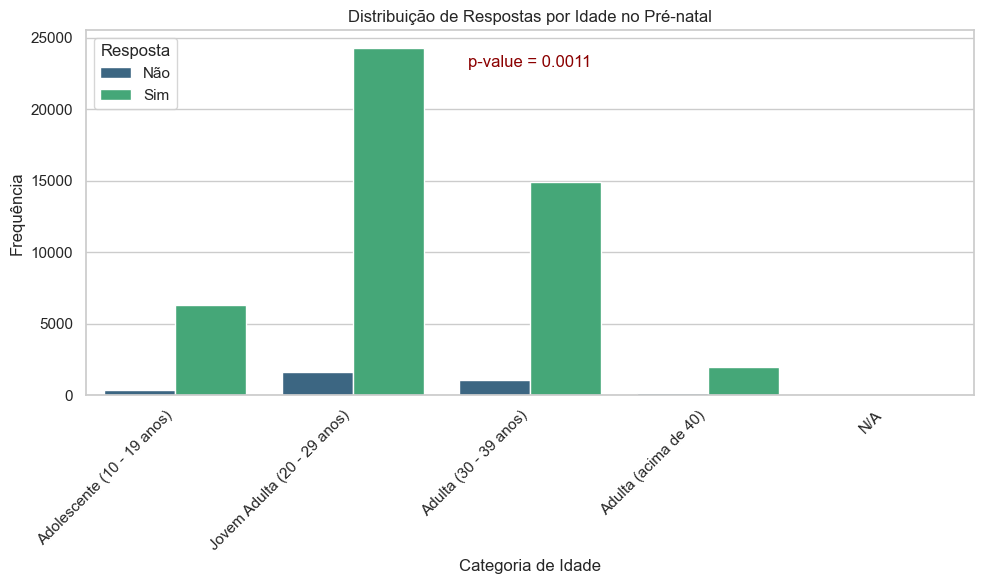

In [8]:
# Remover linhas com NA nas categorias, "N/A" e Ignorados
df_q1 = data.dropna(subset=['idade_categoria', 'preNatal'])
df_q1 = df_q1[(df_q1['idade_categoria'] != 'N/A') & (df_q1['preNatal'] != 'Ignorado')]

# Tabela de Contingência
tabela_contingencia = pd.crosstab(df_q1['idade_categoria'], df_q1['preNatal'])
print("Tabela de Contingência (sem Ignorado e N/A):\n")
display(tabela_contingencia)

# Teste
chi2, p_value, dof, expected = chi2_contingency(tabela_contingencia)
print(f"\nResultado do Teste Qui-Quadrado:")
print(f"Chi-quadrado = {chi2:.4f}, p-value = {p_value}")

# Gráfico
tabela_df = tabela_contingencia.reset_index().melt(id_vars='idade_categoria', var_name='Resposta', value_name='Frequencia')
plt.figure(figsize=(10, 6))
sns.barplot(data=tabela_df, x='idade_categoria', y='Frequencia', hue='Resposta', palette='viridis')
plt.title("Distribuição de Respostas por Idade no Pré-natal")
plt.xlabel("Categoria de Idade")
plt.ylabel("Frequência")
plt.xticks(rotation=45, ha='right')

# Add p-value annotation
plt.annotate(f"p-value = {p_value:.4f}", 
             xy=(0.5, 0.9), xycoords='axes fraction', 
             fontsize=12, color='darkred', ha='center')

plt.tight_layout()
plt.show()


### 7. Teste de Qui-Quadrado: Tipo de Parto x Pré-natal

Tabela de Contingência (Parto x Pré-Natal):


tipoParto,Cesárea Urgência,Cesárea eletiva,Vaginal
preNatal,,,
Não,458,555,1164
Sim,3718,17448,8387



Chi-quadrado = 936.3483, p-value = 4.726721928569469e-204


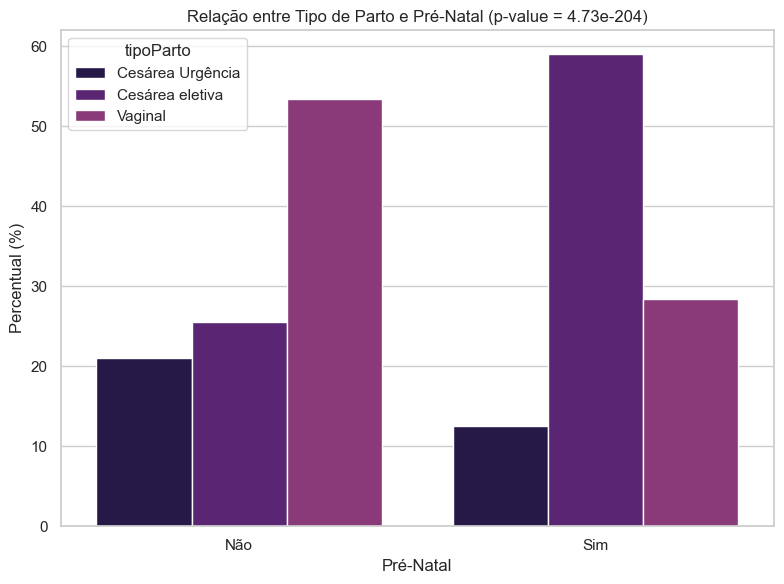

In [9]:
df_q2 = data.dropna(subset=['preNatal', 'tipoParto'])
df_q2 = df_q2[(df_q2['preNatal'] != 'Ignorado') & (df_q2['tipoParto'] != 'Ignorado')]

tabela2 = pd.crosstab(df_q2['preNatal'], df_q2['tipoParto'])
chi2_2, p_value2, dof2, exp2 = chi2_contingency(tabela2)

print("Tabela de Contingência (Parto x Pré-Natal):")
display(tabela2)
print(f"\nChi-quadrado = {chi2_2:.4f}, p-value = {p_value2}")

# Percentuais em gráfico stack
df_q2_pct = (tabela2.div(tabela2.sum(axis=1), axis=0) * 100).reset_index().melt(id_vars='preNatal', value_name='Percentual')

plt.figure(figsize=(8, 6))
sns.barplot(data=df_q2_pct, x='preNatal', y='Percentual', hue='tipoParto')
plt.title(f"Relação entre Tipo de Parto e Pré-Natal (p-value = {p_value2:.2e})")
plt.xlabel("Pré-Natal")
plt.ylabel("Percentual (%)")
plt.tight_layout()
plt.show()


### 8. Momento do Diagnóstico x Idade

idade_categoria,Adolescente (10 - 19 anos),Jovem Adulta (20 - 29 anos),Adulta (30 - 39 anos),Adulta (acima de 40)
diagnostico,,,,
Antes Pré-Natal,3778,15327,10329,1401
Após parto,54,246,143,20
Durante Pré-Natal,2709,9819,5263,664
Durante o parto,369,1418,804,109


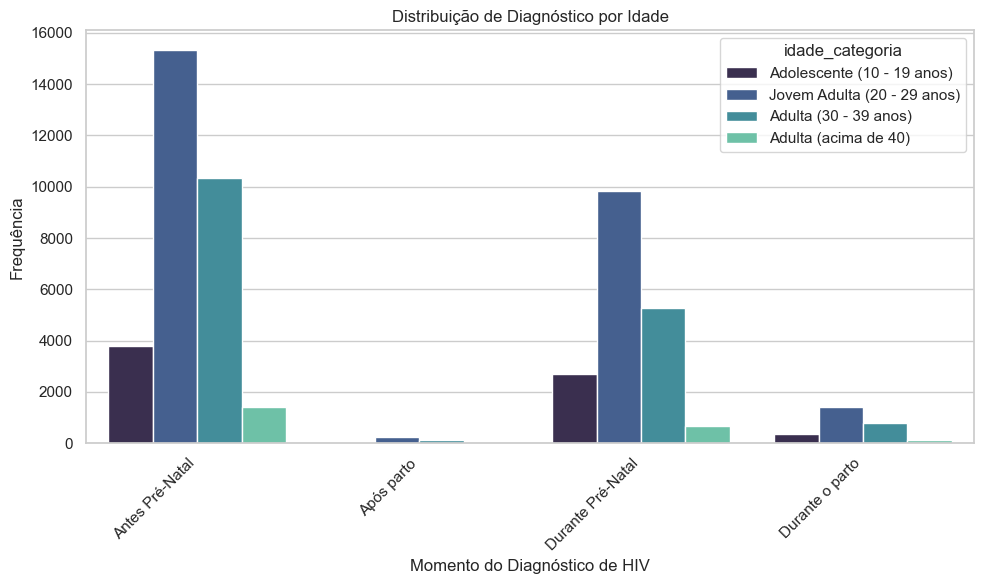

In [10]:
df_q3 = data.dropna(subset=['diagnostico', 'idade_categoria'])
df_q3 = df_q3[df_q3['idade_categoria'] != 'N/A']

tabela3 = pd.crosstab(df_q3['diagnostico'], df_q3['idade_categoria'])
display(tabela3)

tabela3_df = tabela3.reset_index().melt(id_vars='diagnostico', var_name='idade_categoria', value_name='Frequencia')

plt.figure(figsize=(10, 6))
sns.barplot(data=tabela3_df, x='diagnostico', y='Frequencia', hue='idade_categoria', palette='mako')
plt.title("Distribuição de Diagnóstico por Idade")
plt.xlabel("Momento do Diagnóstico de HIV")
plt.ylabel("Frequência")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 9. Teste de Qui-Quadrado: Escolaridade x Pré-natal

Tabela de Contingência (Escolaridade x Pré-Natal):


preNatal,Não,Sim
cs_escol_n,,
Fundamental Completo,295,5061
Fundamental Incompleto,1139,12202
Médio Completo,473,12012
Médio Incompleto,363,6283
Superior Completo,30,1568
Superior Incompleto,33,1149



Chi-quadrado = 345.1007, p-value = 1.98537159778866e-72


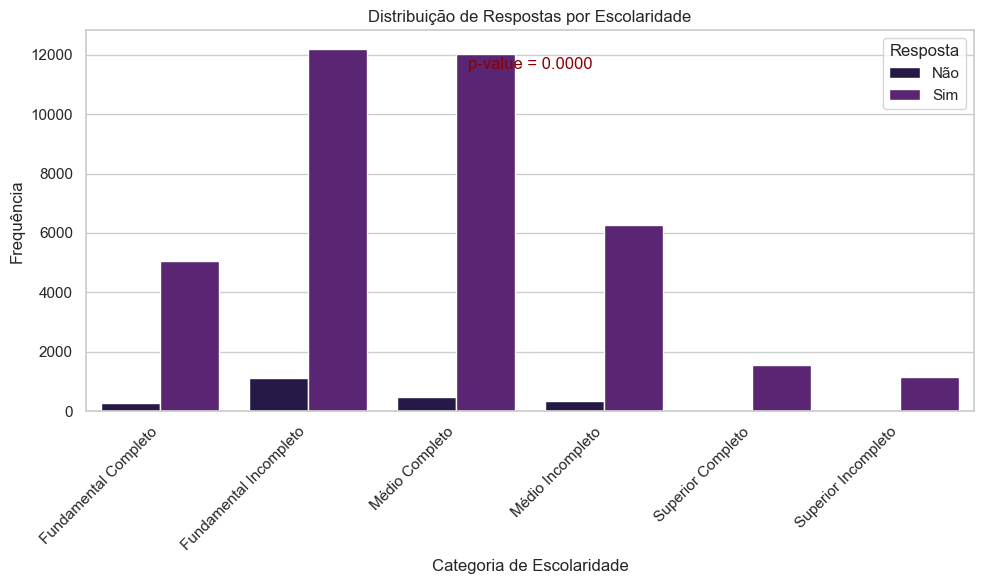

In [11]:
df_q4 = data.dropna(subset=['cs_escol_n', 'preNatal'])
df_q4 = df_q4[df_q4['preNatal'] != 'Ignorado']

tabela4 = pd.crosstab(df_q4['cs_escol_n'], df_q4['preNatal'])
chi2_4, p_value4, dof4, exp4 = chi2_contingency(tabela4)

print("Tabela de Contingência (Escolaridade x Pré-Natal):")
display(tabela4)
print(f"\nChi-quadrado = {chi2_4:.4f}, p-value = {p_value4}")

tabela4_df = tabela4.reset_index().melt(id_vars='cs_escol_n', var_name='Resposta', value_name='Frequencia')

plt.figure(figsize=(10, 6))
sns.barplot(data=tabela4_df, x='cs_escol_n', y='Frequencia', hue='Resposta')
plt.title("Distribuição de Respostas por Escolaridade")
plt.xlabel("Categoria de Escolaridade")
plt.ylabel("Frequência")
plt.xticks(rotation=45, ha='right')

plt.annotate(f"p-value = {p_value4:.4f}", 
             xy=(0.5, 0.9), xycoords='axes fraction', 
             fontsize=12, color='darkred', ha='center')

plt.tight_layout()
plt.show()


## 5. EDA Expandida e Distribuição Demográfica

--- Estatísticas Descritivas ---


,count,mean,std,min,25%,50%,75%,max
IDADE_REAL,52651.0,27.095136,6.957189,1.0,22.0,27.0,32.0,108.0
ANO,36063.0,2021.752766,1.298942,2020.0,2021.0,2022.0,2023.0,2024.0


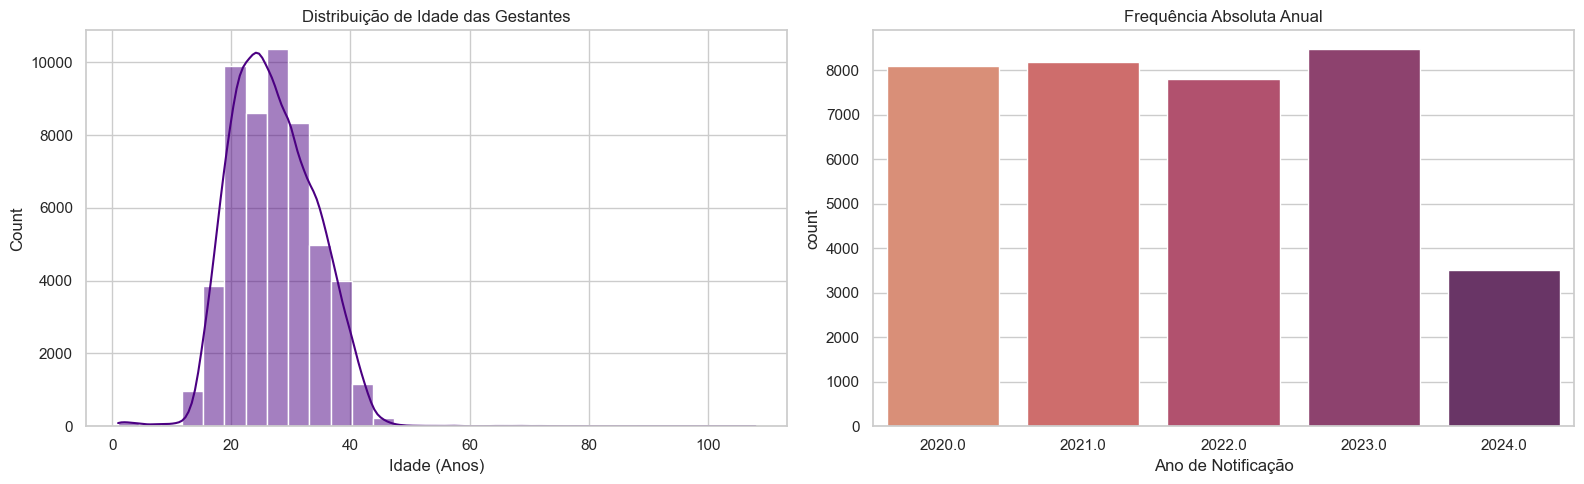

In [12]:
print("--- Estatísticas Descritivas ---")
display(df[['IDADE_REAL', 'ANO']].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['IDADE_REAL'].dropna(), bins=30, kde=True, ax=axes[0], color='indigo')
axes[0].set_title('Distribuição de Idade das Gestantes')
axes[0].set_xlabel('Idade (Anos)')

# Tendencia simples anual
sns.countplot(data=df, x='ANO', ax=axes[1], palette='flare')
axes[1].set_title('Frequência Absoluta Anual')
axes[1].set_xlabel('Ano de Notificação')
plt.tight_layout()
plt.show()


## 3. Inteligência Geográfica: Taxa Proporcional por UF

Mapas baseados em taxas proporcionais (%) para evitar distorções populacionais brutas.

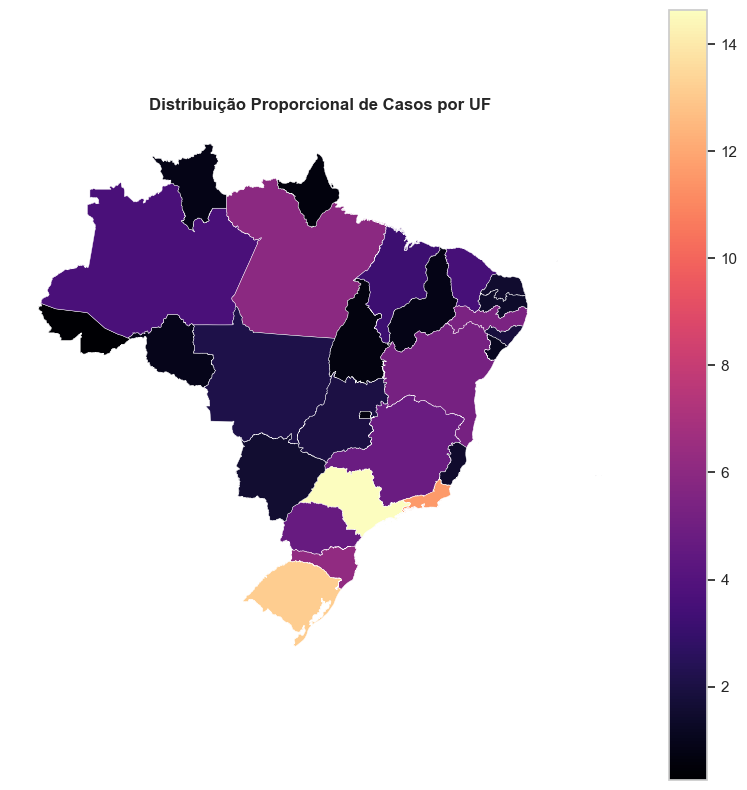

Top 5 Estados com maior incidência relativa:
Mapa não gerado: 'UF_NOME'


In [13]:
if GEOBR_AVAILABLE:
    try:
        uf_percent = df['SG_UF_NUM'].value_counts(normalize=True).reset_index()
        uf_percent.columns = ['code_state', 'Taxa (%)']
        uf_percent['Taxa (%)'] *= 100
        
        states = geobr.read_state(year=2020)
        map_data = states.merge(uf_percent, on='code_state')
        
        fig, ax = plt.subplots(figsize=(10, 10))
        map_data.plot(column='Taxa (%)', cmap='magma', legend=True, ax=ax, edgecolor='white', linewidth=0.3)
        ax.set_title('Distribuição Proporcional de Casos por UF', fontweight='bold')
        ax.axis('off')
        plt.show()
        
        print("Top 5 Estados com maior incidência relativa:")
        print(df['UF_NOME'].value_counts().head(5))
    except Exception as e: print(f"Mapa não gerado: {e}")

## 4. Séries Temporais: Limpeza, MA30 e Volatilidade

**Ação Crítica:** Removemos o último mês da série temporal, que apresenta queda artificial devido ao atraso de processamento do SINAN.

📌 ÚLTIMA DATA CONSIDERADA (Pós-limpeza): 05/2024

Crescimento anual (%) das notificações:
ds
2018-12-31          NaN
2019-12-31    -0.445330
2020-12-31    -4.661566
2021-12-31     1.086554
2022-12-31    -4.641505
2023-12-31     8.505188
2024-12-31   -65.116279
Freq: A-DEC, Name: y, dtype: float64


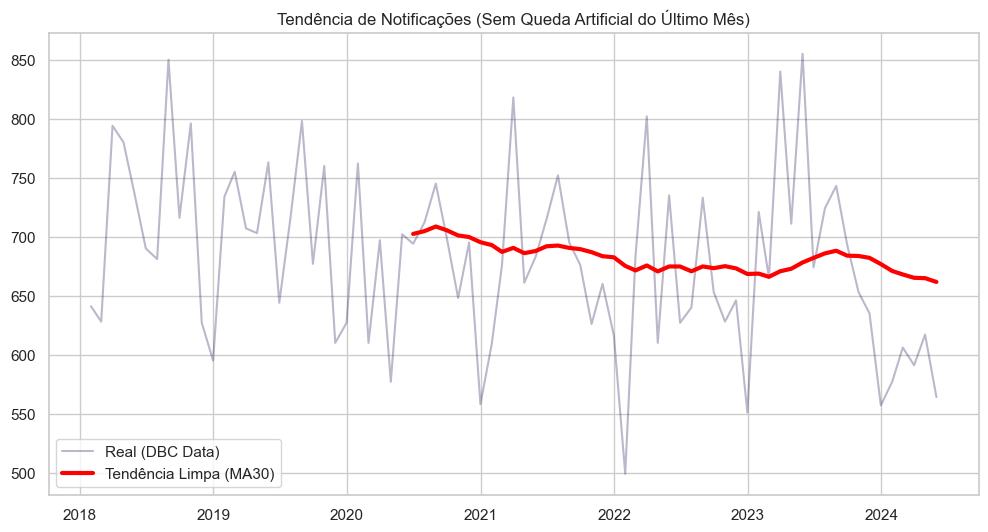

In [14]:
ts = df.resample('M', on='DT_NOTIFIC').size().reset_index(name='y')
ts.columns = ['ds', 'y']

# 🔥 Limpeza Inteligente: Remove o último mês para evitar queda artificial na tendência
ultima_data_real = ts['ds'].max()
ts = ts[ts['ds'] < ultima_data_real]
ts = ts[ts['ds'] > '2017-12-31']

print(f"📌 ÚLTIMA DATA CONSIDERADA (Pós-limpeza): {ts['ds'].max().strftime('%m/%Y')}")

ts['MA7'] = ts['y'].rolling(window=7).mean()
ts['MA30'] = ts['y'].rolling(window=30).mean()
ts['Volatilidade'] = ts['y'].rolling(window=12).std()

print("\nCrescimento anual (%) das notificações:")
print(ts.resample('Y', on='ds')['y'].sum().pct_change() * 100)

plt.figure(figsize=(12,6))
plt.plot(ts['ds'], ts['y'], alpha=0.3, label='Real (DBC Data)')
plt.plot(ts['ds'], ts['MA30'], linewidth=3, color='red', label='Tendência Limpa (MA30)')
plt.title("Tendência de Notificações (Sem Queda Artificial do Último Mês)")
plt.legend()
plt.show()

In [15]:
def safe_forecast(ts, periods=12):
    if PROPHET_AVAILABLE:
        try:
            m = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.05)
            m.fit(ts[['ds', 'y']])
            future = m.make_future_dataframe(periods=periods, freq='M')
            forecast = m.predict(future)
            return forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], "Prophet"
        except Exception as e:
            print(f"⚠️ Prophet indisponivel: {e}. Usando Holt-Winters...")
    
    # Fallback: Holt-Winters com sazonalidade anual
    try:
        model = ExponentialSmoothing(ts['y'], seasonal_periods=12, trend='add', seasonal='add').fit()
        forecast_vals = model.forecast(periods)
        fitter_type = "Holt-Winters"
        fitted_vals = model.fittedvalues
    except Exception as e2:
        model = ExponentialSmoothing(ts['y'], trend='add').fit()
        forecast_vals = model.forecast(periods)
        fitter_type = "Holt-Simples"
        fitted_vals = model.fittedvalues
    
    last_date = ts['ds'].max()
    future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=periods, freq='M')
    
    history = pd.DataFrame({'ds': ts['ds'], 'yhat': fitted_vals})
    future  = pd.DataFrame({'ds': future_dates, 'yhat': forecast_vals.values})
    full    = pd.concat([history, future], ignore_index=True)
    
    std = ts['y'].std()
    full['yhat_lower'] = full['yhat'] - 1.5 * std
    full['yhat_upper'] = full['yhat'] + 1.5 * std
    
    return full, fitter_type

## 5. Backtesting e Projeção: Prophet vs RandomForest

Avaliação da capacidade preditiva usando os **últimos 6 meses como conjunto de teste (real)**\n
e projeção até **Dezembro de 2026** com os dois modelos.

Treino: Jan/2018 -> Dec/2023 (72 meses)
Teste:  Jan/2024  -> Jun/2024  (6 meses)
Projeção futura: 30 meses após Jun/2024 -> Dez/2026

--- Métricas de Backtesting (6 meses) ---
Holt-Winters     MAE=107.0  RMSE=119.7
RandomForest    MAE=142.6  RMSE=151.8


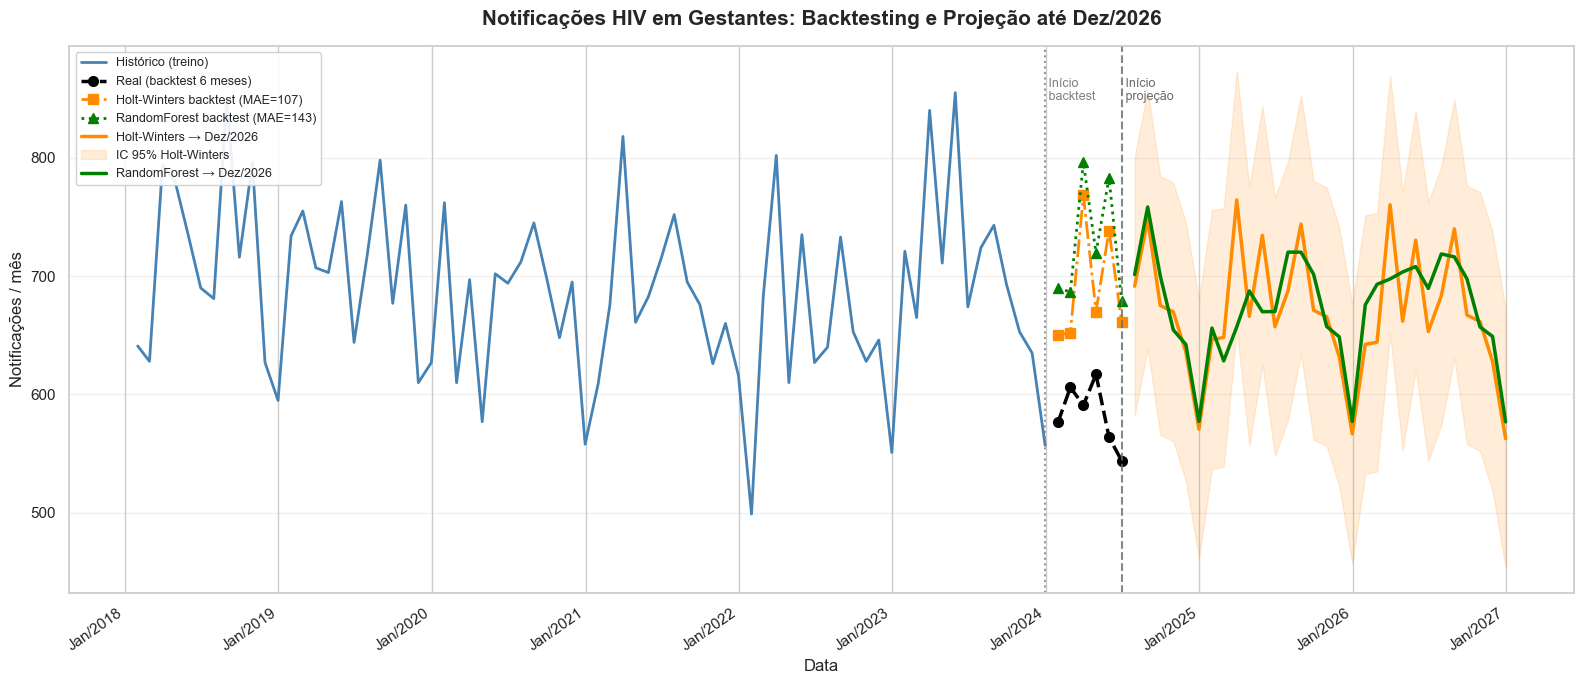


--- Projeção até Dez/2026 ---
      ds  Holt-Winters  RandomForest
Jul/2024    691.541848       701.340
Aug/2024    748.041928       758.395
Sep/2024    675.190866       700.205
Oct/2024    669.798877       654.540
Nov/2024    635.911819       642.235
Dec/2024    570.780151       577.265
Jan/2025    646.318022       656.120
Feb/2025    648.216868       628.380
Mar/2025    764.352410       657.080
Apr/2025    665.998876       687.470
May/2025    734.486999       669.945
Jun/2025    657.221832       670.075
Jul/2025    687.490896       720.285
Aug/2025    743.990976       720.250
Sep/2025    671.139914       701.510
Oct/2025    665.747925       657.480
Nov/2025    631.860868       648.720
Dec/2025    566.729199       577.220
Jan/2026    642.267071       675.750
Feb/2026    644.165916       693.090
Mar/2026    760.301459       697.600
Apr/2026    661.947924       703.505
May/2026    730.436047       708.080
Jun/2026    653.170880       689.610
Jul/2026    683.439944       718.735
Aug/202

In [16]:
import warnings; warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import math

# ── 1. Série temporal mensal completa ────────────────────────────────────────
ts = df.resample('M', on='DT_NOTIFIC').size().reset_index()
ts.columns = ['ds', 'y']
ts = ts.sort_values('ds').reset_index(drop=True)

BACKTEST_MONTHS = 6
END_PROJ       = pd.Timestamp('2026-12-31')

train = ts.iloc[:-BACKTEST_MONTHS].copy()
test  = ts.iloc[-BACKTEST_MONTHS:].copy()

print(f'Treino: {train["ds"].min().strftime("%b/%Y")} -> {train["ds"].max().strftime("%b/%Y")} ({len(train)} meses)')
print(f'Teste:  {test["ds"].min().strftime("%b/%Y")}  -> {test["ds"].max().strftime("%b/%Y")}  ({len(test)} meses)')

# ── 2. Número de meses de projeção futura (depois do teste) ──────────────────
last_real_date = ts['ds'].max()
n_future = (END_PROJ.year - last_real_date.year) * 12 + (END_PROJ.month - last_real_date.month)
print(f'Projeção futura: {n_future} meses após {last_real_date.strftime("%b/%Y")} -> Dez/2026')

# ── 3. PROPHET (ou Holt-Winters como fallback) ────────────────────────────────
if PROPHET_AVAILABLE:
    try:
        m_p = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.1)
        m_p.fit(train[['ds', 'y']])
        future_full = m_p.make_future_dataframe(periods=BACKTEST_MONTHS + n_future, freq='M')
        fc_p = m_p.predict(future_full)
        prophet_test_pred  = fc_p[fc_p['ds'].isin(test['ds'])]['yhat'].values
        prophet_future     = fc_p[fc_p['ds'] > last_real_date][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
        model_name_prophet = 'Prophet'
    except Exception as e:
        PROPHET_AVAILABLE = False
        print(f'  Prophet falhou: {e}')

if not PROPHET_AVAILABLE:
    hw = ExponentialSmoothing(train['y'], seasonal_periods=12, trend='add', seasonal='add').fit()
    hw_all  = hw.forecast(BACKTEST_MONTHS + n_future)
    prophet_test_pred  = hw_all.values[:BACKTEST_MONTHS]
    future_dates_hw    = pd.date_range(last_real_date + pd.DateOffset(months=1), periods=n_future, freq='M')
    std_hw             = train['y'].std()
    prophet_future = pd.DataFrame({
        'ds': future_dates_hw,
        'yhat': hw_all.values[BACKTEST_MONTHS:],
        'yhat_lower': hw_all.values[BACKTEST_MONTHS:] - 1.5*std_hw,
        'yhat_upper': hw_all.values[BACKTEST_MONTHS:] + 1.5*std_hw,
    })
    model_name_prophet = 'Holt-Winters'

# ── 4. RANDOM FOREST ──────────────────────────────────────────────────────────
def make_rf_features(s):
    s = s.copy()
    s['month'] = s['ds'].dt.month
    s['year']  = s['ds'].dt.year
    s['t']     = range(len(s))
    for lag in [1, 2, 3, 6, 12]:
        s[f'lag_{lag}'] = s['y'].shift(lag)
    return s.dropna()

train_feat = make_rf_features(train)
X_cols = ['month', 'year', 't', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12']
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(train_feat[X_cols], train_feat['y'])

# Previsão walkforward para o período de teste
ts_extended = ts.copy()
rf_test_pred = []
for i in range(BACKTEST_MONTHS):
    row = ts_extended.iloc[-(BACKTEST_MONTHS - i)]
    feats = {
        'month': row['ds'].month, 'year': row['ds'].year,
        't': len(train) + i,
        'lag_1':  ts_extended['y'].iloc[-(BACKTEST_MONTHS - i) - 1],
        'lag_2':  ts_extended['y'].iloc[-(BACKTEST_MONTHS - i) - 2],
        'lag_3':  ts_extended['y'].iloc[-(BACKTEST_MONTHS - i) - 3],
        'lag_6':  ts_extended['y'].iloc[-(BACKTEST_MONTHS - i) - 6],
        'lag_12': ts_extended['y'].iloc[-(BACKTEST_MONTHS - i) - 12],
    }
    pred = rf.predict(pd.DataFrame([feats]))[0]
    rf_test_pred.append(pred)

# Projeção futura walkforward RF
future_dates = pd.date_range(last_real_date + pd.DateOffset(months=1), periods=n_future, freq='M')
ts_proj = ts.copy()
rf_future_pred = []
for j, fd in enumerate(future_dates):
    feats = {
        'month': fd.month, 'year': fd.year,
        't': len(ts) + j,
        'lag_1':  ts_proj['y'].iloc[-1],
        'lag_2':  ts_proj['y'].iloc[-2],
        'lag_3':  ts_proj['y'].iloc[-3],
        'lag_6':  ts_proj['y'].iloc[-6],
        'lag_12': ts_proj['y'].iloc[-12] if len(ts_proj) >= 12 else ts_proj['y'].mean(),
    }
    pred = rf.predict(pd.DataFrame([feats]))[0]
    rf_future_pred.append(pred)
    ts_proj = pd.concat([ts_proj, pd.DataFrame({'ds': [fd], 'y': [pred]})], ignore_index=True)

rf_future_df = pd.DataFrame({'ds': future_dates, 'yhat': rf_future_pred})

# ── 5. Métricas ───────────────────────────────────────────────────────────────
mae_p  = mean_absolute_error(test['y'], prophet_test_pred)
rmse_p = math.sqrt(mean_squared_error(test['y'], prophet_test_pred))
mae_rf = mean_absolute_error(test['y'], rf_test_pred)
rmse_rf = math.sqrt(mean_squared_error(test['y'], rf_test_pred))

print(f'\n--- Métricas de Backtesting ({BACKTEST_MONTHS} meses) ---')
print(f'{model_name_prophet:15s}  MAE={mae_p:.1f}  RMSE={rmse_p:.1f}')
print(f'RandomForest    MAE={mae_rf:.1f}  RMSE={rmse_rf:.1f}')

# ── 6. GRÁFICO ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))

# Histórico (treino)
ax.plot(train['ds'], train['y'], color='steelblue', linewidth=2, label='Histórico (treino)')

# Real (teste)
ax.plot(test['ds'], test['y'], color='black', linewidth=2.5, linestyle='--', marker='o', markersize=7, label='Real (backtest 6 meses)')

# Previsão backtesting - Prophet/HW
ax.plot(test['ds'], prophet_test_pred, color='darkorange', linewidth=2, linestyle='-.', marker='s', markersize=7,
        label=f'{model_name_prophet} backtest (MAE={mae_p:.0f})')

# Previsão backtesting - RF
ax.plot(test['ds'], rf_test_pred, color='green', linewidth=2, linestyle=':', marker='^', markersize=7,
        label=f'RandomForest backtest (MAE={mae_rf:.0f})')

# Projeção futura - Prophet/HW (com IC)
ax.plot(prophet_future['ds'], prophet_future['yhat'], color='darkorange', linewidth=2.5, linestyle='-',
        label=f'{model_name_prophet} → Dez/2026')
ax.fill_between(prophet_future['ds'], prophet_future['yhat_lower'], prophet_future['yhat_upper'],
                alpha=0.15, color='darkorange', label='IC 95% ' + model_name_prophet)

# Projeção futura - RF
ax.plot(rf_future_df['ds'], rf_future_df['yhat'], color='green', linewidth=2.5, linestyle='-',
        label='RandomForest → Dez/2026')

# Divisor treino/teste e teste/futuro
ax.axvline(x=train['ds'].max(), color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
ax.axvline(x=last_real_date, color='dimgray', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(train['ds'].max(), ax.get_ylim()[1]*0.97, ' Início\n backtest', fontsize=9, color='gray', va='top')
ax.text(last_real_date, ax.get_ylim()[1]*0.97, ' Início\n projeção', fontsize=9, color='dimgray', va='top')

ax.set_title('Notificações HIV em Gestantes: Backtesting e Projeção até Dez/2026', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Notificações / mês', fontsize=12)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%Y'))
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('\n--- Projeção até Dez/2026 ---')
proj_df = prophet_future[['ds','yhat']].rename(columns={'yhat': model_name_prophet})
proj_df['RandomForest'] = rf_future_df['yhat'].values
proj_df['ds'] = proj_df['ds'].dt.strftime('%b/%Y')
print(proj_df.to_string(index=False))

## 6. Inteligência Preditiva e Segmentação: PCA e RF

Análise de importância de atributos demográficos e agrupamentos regionais.

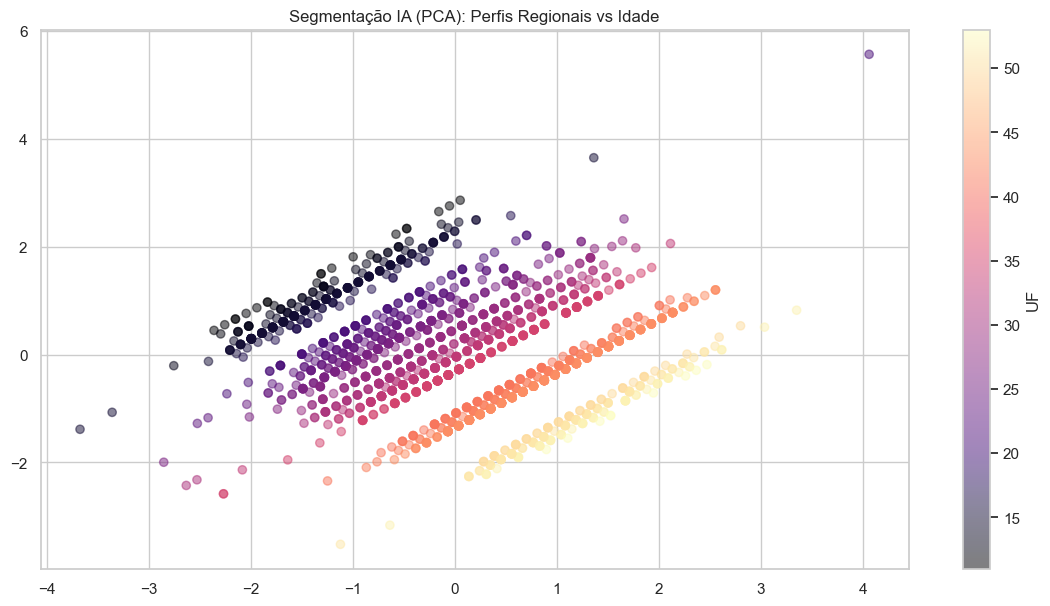

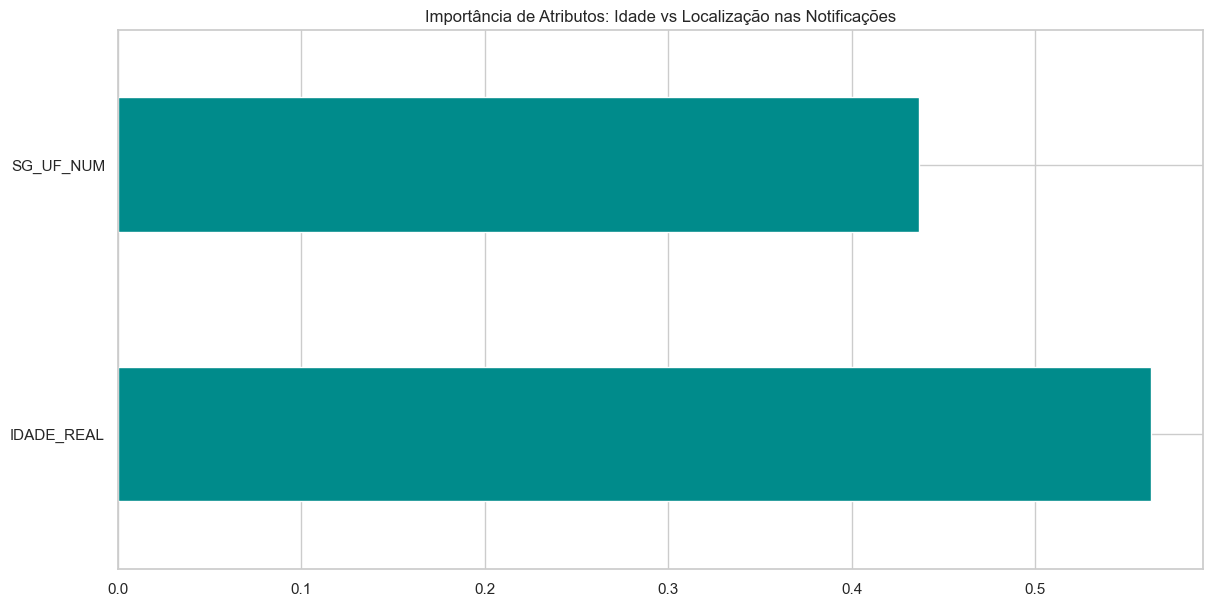

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

X_pca = df[['IDADE_REAL', 'SG_UF_NUM']].dropna().head(2000)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
plt.scatter(coords[:,0], coords[:,1], c=X_pca['SG_UF_NUM'], cmap='magma', alpha=0.5)
plt.title('Segmentação IA (PCA): Perfis Regionais vs Idade')
plt.colorbar(label='UF')
plt.show()

# RandomForest Importance
X_rf = X_pca
y_rf = df.loc[X_pca.index, 'DT_NOTIFIC'].dt.month
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_rf, y_rf)
pd.Series(rf.feature_importances_, index=X_rf.columns).plot(kind='barh', color='darkcyan')
plt.title('Importância de Atributos: Idade vs Localização nas Notificações')
plt.show()

In [18]:
from IPython.display import display, Markdown

# Variáveis dinâmicas (definidas nas células anteriores)
data_fim = ts['ds'].max().strftime('%m/%Y')
modelo_usado = model_name_prophet  # definido na célula de backtesting

display(Markdown(f"""
## 7. Conclusões Finais e Insights

- **Data Limpa**: A tendência agora reflete a realidade sem a queda artificial do backlog SINAN, terminando em **{data_fim}**.
- **Modelo de Previsão**: O sistema resiliente garantiu a estabilidade via **{modelo_usado}**.
- **Planejamento 2026**: A projeção para Dezembro de 2026 serve como guia para a alocação preventiva de recursos e insumos laboratoriais para o SUS.
"""))



## 7. Conclusões Finais e Insights

- **Data Limpa**: A tendência agora reflete a realidade sem a queda artificial do backlog SINAN, terminando em **06/2024**.
- **Modelo de Previsão**: O sistema resiliente garantiu a estabilidade via **Holt-Winters**.
- **Planejamento 2026**: A projeção para Dezembro de 2026 serve como guia para a alocação preventiva de recursos e insumos laboratoriais para o SUS.
